In [1]:
from pathlib import Path
import pandas as pd

from decent_bench.utils.checkpoint_manager import CheckpointManager

In [2]:
metrics = {"accuracy", "loss", "consensus error", "nr gradient calls"}

In [3]:
checkpoint_dirs = Path(r"results/heterogeneous")
if not checkpoint_dirs.is_dir():
    raise ValueError(f"Checkpoint directory {checkpoint_dirs} does not exist")

ValueError: Checkpoint directory results/heterogeneous does not exist

In [ ]:
data = []
for checkpoint in Path(r"results/heterogeneous/5_4_None_None_None_None").iterdir():
    if not checkpoint.is_dir():
        display(f"Skipping {checkpoint} since it is not a directory")
        continue
    checkpoint_manager = CheckpointManager(checkpoint)
    try:
        metrics_result = checkpoint_manager.load_metrics_result(skip_agent_metrics=True)
    except Exception as e:
        display(f"Error loading metrics result for {checkpoint}: {e}")
        continue
    for alg, table in metrics_result.table_results.items():
        alg_data = {"algorithm": alg.name}  # + "-" + checkpoint.name.replace("mnist", "")}
        for metric, values in table.items():
            if metric.table_description not in metrics:
                continue
            for statistic, value in values.items():
                if statistic != "avg":
                    continue
                alg_data[metric.table_description] = value[0]
        data.append(alg_data)
df = pd.DataFrame(data)

In [ ]:
df

In [4]:
dfs = {}
for checkpoint_dir in checkpoint_dirs.iterdir():
    data = []
    for checkpoint in checkpoint_dir.iterdir():
        if not checkpoint.is_dir():
            display(f"Skipping {checkpoint} since it is not a directory")
            continue
        checkpoint_manager = CheckpointManager(checkpoint)
        try:
            metrics_result = checkpoint_manager.load_metrics_result(skip_agent_metrics=True)
        except Exception as e:
            display(f"Error loading metrics result for {checkpoint}: {e}")
            continue
        for alg, table in metrics_result.table_results.items():
            alg_data = {"algorithm": alg.name}  # + "-" + checkpoint.name.replace("mnist", "")}
            for metric, values in table.items():
                if metric.table_description not in metrics:
                    continue
                for statistic, value in values.items():
                    if statistic != "avg":
                        continue
                    alg_data[metric.table_description] = value[0]
            data.append(alg_data)
    dfs[checkpoint_dir.name] = pd.DataFrame(data)

"Error loading metrics result for results/heterogeneous/5_4_None_None_True_None/LT-ADMM-EMA: [Errno 2] No such file or directory: 'results/heterogeneous/5_4_None_None_True_None/LT-ADMM-EMA/metric_computation.pkl'"

"Error loading metrics result for results/heterogeneous/10_2_None_True_None_None/LT-ADMM-VR: [Errno 2] No such file or directory: 'results/heterogeneous/10_2_None_True_None_None/LT-ADMM-VR/metric_computation.pkl'"

"Error loading metrics result for results/heterogeneous/10_2_None_True_None_None/LT-ADMM-EMA-OPT: [Errno 2] No such file or directory: 'results/heterogeneous/10_2_None_True_None_None/LT-ADMM-EMA-OPT/metric_computation.pkl'"

In [5]:
algorithms = [
    "DGD",
    "KGT",
    "LED",
    "LT-ADMM-ls",
    "LT-ADMM-EMA-ls",
    "LT-ADMM-EMA-OPT",
    "LT-ADMM-TORCH",
    "LT-ADMM-VR",
    "ProxSkip",
]
tokens = {
    "ls",
    "ss1",
    "ss2",
    "ss",
    "aux_ss",
    "comm_prob",
    "ema",
}
token_conversion = {
    "ss": "ss1",
    "aux_ss": "ss2",
}

results = []
for experiment, df in dfs.items():
    experiment_data = experiment.split("_")
    n_agents, n_neighbors, drops, activity, compression, noise = experiment_data
    n_agents, n_neighbors = int(n_agents), int(n_neighbors)
    for alg in algorithms:
        alg_df = df[df["algorithm"].str.contains(alg)].copy()

        if alg_df.empty:
            display(f"No results found for algorithm {alg} in experiment {experiment}")
            continue

        alg_df.sort_values("accuracy", ascending=False, inplace=True)
        alg_name = alg_df["algorithm"].iloc[0].split("-")
        res = {}
        while len(alg_name) > 0:
            token = alg_name.pop(0)
            token = token_conversion.get(token, token)
            if token in tokens:
                value = float(alg_name.pop(0))
                res[token] = value
        data = {
            "algorithm": alg,
            "n_agents": n_agents,
            "n_neighbors": n_neighbors,
            "drops": drops,
            "activity": activity,
            "compression": compression,
            "noise": noise,
            "accuracy": alg_df["accuracy"].iloc[0],
            "loss": alg_df["loss"].iloc[0],
            "consensus error": alg_df["consensus error"].iloc[0],
            "nr gradient calls": alg_df["nr gradient calls"].iloc[0],
        }
        data.update(res)
        results.append(data)

final_result = pd.DataFrame(results)

'No results found for algorithm LT-ADMM-EMA-ls in experiment 5_4_None_None_True_None'

'No results found for algorithm LT-ADMM-EMA-OPT in experiment 5_4_None_None_True_None'

'No results found for algorithm LT-ADMM-TORCH in experiment 5_4_None_None_True_None'

'No results found for algorithm LT-ADMM-VR in experiment 5_4_None_None_True_None'

'No results found for algorithm LT-ADMM-EMA-OPT in experiment 10_2_None_True_None_None'

'No results found for algorithm LT-ADMM-TORCH in experiment 10_2_None_True_None_None'

'No results found for algorithm LT-ADMM-VR in experiment 10_2_None_True_None_None'

In [7]:
final_result

,algorithm,n_agents,n_neighbors,drops,activity,compression,noise,accuracy,loss,consensus error,nr gradient calls,ss1,ss2,ls,ema,comm_prob
0,DGD,10,2,None,None,None,None,0.48078,3.212831e-02,2.276906e-01,32000.0,0.100,1.000,NaN,NaN,NaN
1,KGT,10,2,None,None,None,None,0.90214,3.029927e-01,2.303255e-02,480000.0,0.010,0.500,15.0,NaN,NaN
2,LED,10,2,None,None,None,None,0.89914,2.795306e-01,1.408752e-02,160000.0,0.010,0.100,5.0,NaN,NaN
3,LT-ADMM-ls,10,2,None,None,None,None,0.86630,4.647844e-01,3.532733e-03,640000.0,0.001,0.010,20.0,NaN,NaN
4,LT-ADMM-EMA-ls,10,2,None,None,None,None,0.86398,4.503879e-01,2.202223e-03,640000.0,0.001,0.010,20.0,0.6,NaN
5,LT-ADMM-EMA-OPT,10,2,None,None,None,None,0.26492,3.777451e-01,2.941242e+00,640000.0,0.001,0.010,20.0,0.7,NaN
6,LT-ADMM-TORCH,10,2,None,None,None,None,0.19804,3.905386e+00,6.663043e+00,480000.0,0.001,0.010,15.0,NaN,NaN
7,LT-ADMM-VR,10,2,None,None,None,None,0.86380,4.504395e-01,7.273512e-04,1280000.0,0.001,0.010,20.0,NaN,NaN
8,ProxSkip,10,2,None,None,None,None,0.71690,1.078306e+00,8.568754e-02,32000.0,0.010,0.500,NaN,NaN,0.20
9,DGD,5,4,None,None,True,None,0.84368,2.841811e-01,1.142733e-01,32000.0,0.100,1.000,NaN,NaN,NaN


[04/05/26 22:08:02] INFO     No checkpoint manager provided, running benchmark without            ]8;id=242897;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=6686;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#267\267]8;;\
                             checkpointing. Progress cannot be resumed if interrupted.                             

                    INFO     Starting benchmark execution                                         ]8;id=887730;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=786259;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#353\353]8;;\

Output()

[04/05/26 22:08:39] INFO     Benchmark execution complete, thanks for using decent-bench          ]8;id=739523;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=453839;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#371\371]8;;\

Output()

Output()

[04/05/26 22:08:41] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=736619;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=659155;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=256812;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=855728;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+               
                             | Metric (statistic)      | LT-ADMM 1           | LT-ADMM 2           |               
                             +=========================+=====================+=====================+               
                             | consensus error (min)   | 5.69e-01 ± 0.00e+00 | 2.44e-01 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | consensus error (avg)   | 7.03e-01 ± 0.00e+00 | 2.48e-01 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | consensus error (max)   | 1.04e+00 ± 0.00e+00 | 2.52e-01 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr gradient calls (avg) | 1.28e+05 ± 0.00e+00 | 1.29e+05 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr gradient calls (sum) | 6.38e+05 ± 0.00e+00 | 6.43e+05 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr sent messages (avg)  | 1.27e+03 ± 0.00e+00 | 1.29e+03 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr sent messages (sum)  | 6.37e+03 ± 0.00e+00 | 6.46e+03 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (min)          | 73.24% ± 0.00%      | 10.32% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (avg)          | 77.51% ± 0.00%      | 10.68% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (max)          | 81.00% ± 0.00%      | 11.04% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (min)         | 73.24% ± 0.00%      | 10.32% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (avg)         | 77.51% ± 0.00%      | 10.68% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (max)         | 81.00% ± 0.00%      | 11.04% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | recall (min)            | 73.24% ± 0.00%      | 10.32% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | recall (avg)            | 77.51% ± 0.00%      | 10.68% ± 0.00%    

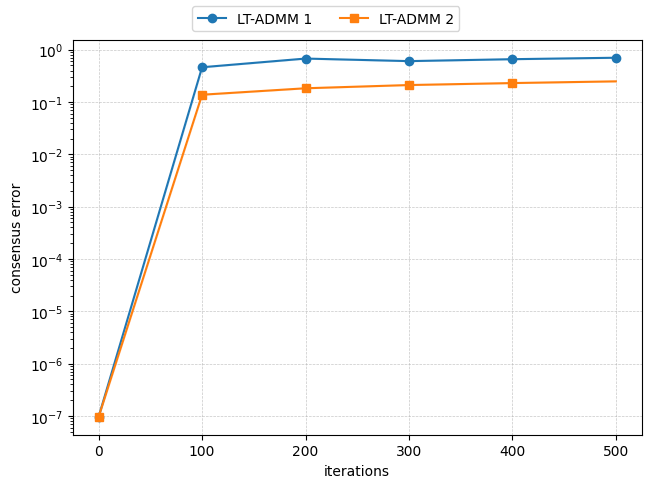

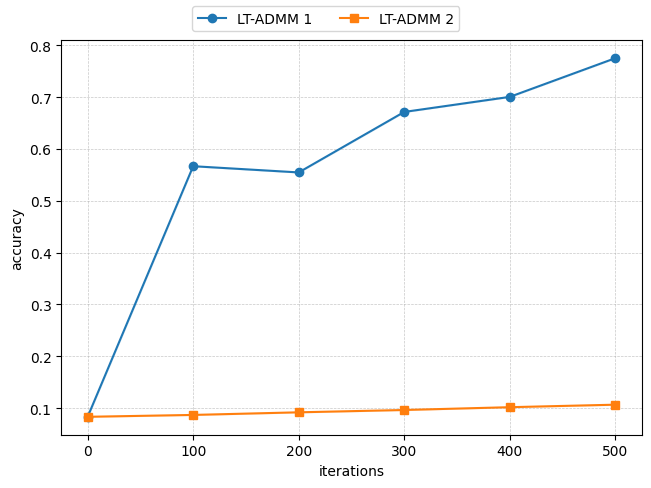

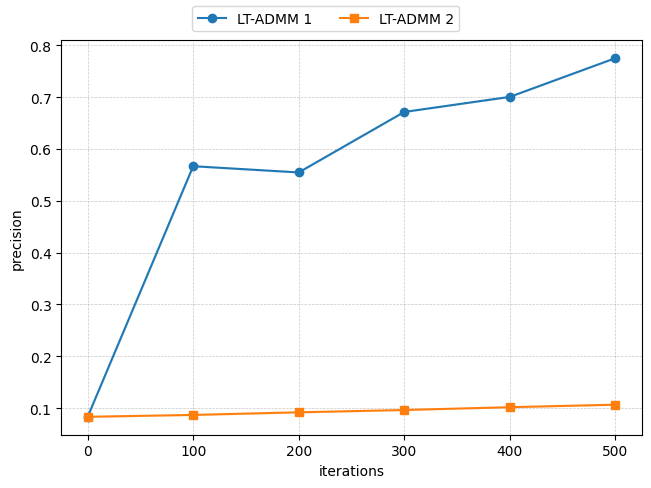

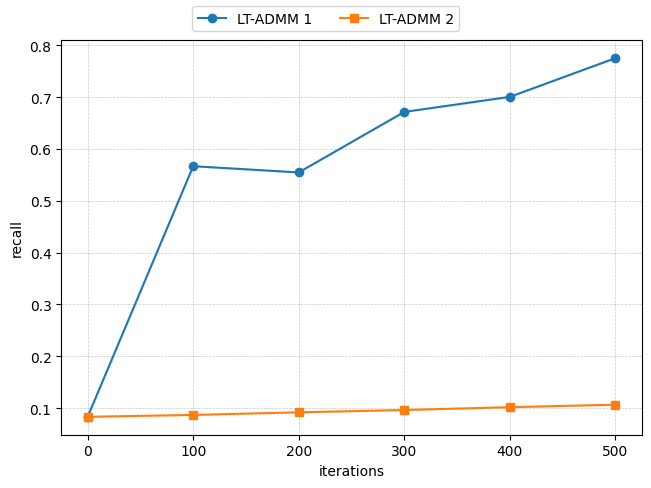

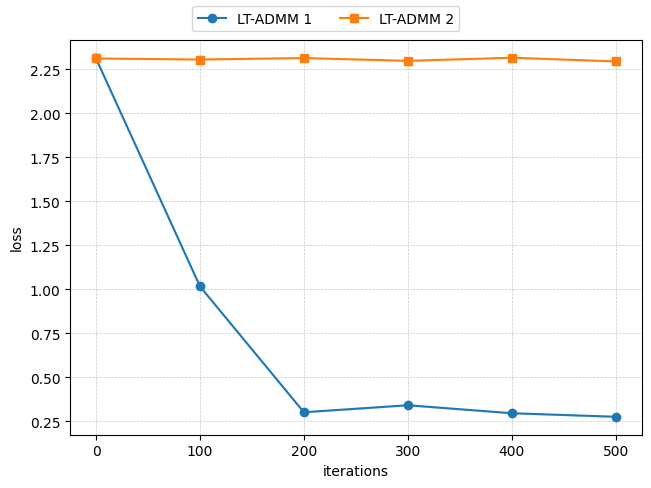

In [1]:
import ctypes
import gc
from pathlib import Path

import networkx as nx
import numpy as np
import torch
from torch import nn
from torchvision import transforms
from torchvision.datasets import MNIST

import decent_bench.algorithms.decentralized as dec_algorithms
import decent_bench.utils.interoperability as iop
from decent_bench import benchmark
from decent_bench.agents import Agent
from decent_bench.algorithms.utils import pytorch_initialization
from decent_bench.costs import PyTorchCost
from decent_bench.datasets import PyTorchDatasetHandler
from decent_bench.metrics import metric_library as ml
from decent_bench.networks import P2PNetwork
from decent_bench.schemes import GaussianNoise, TopK, UniformActivationRate, UniformDropRate
from decent_bench.utils.checkpoint_manager import CheckpointManager
from decent_bench.utils.pytorch_utils import ArgmaxActivation, SimpleLinearModel
from decent_bench.utils.types import SupportedDevices, SupportedFrameworks
from examples.nim.src.algorithms.lt_admm_ema import LT_ADMM_EMA
from examples.nim.src.algorithms.lt_admm_torch_optimizer import LT_ADMM_TORCH


iterations = 500
state_snapshot_period = 100
samples_per_partition = 1000
device = SupportedDevices.CPU
opt_cls = torch.optim.Adam
iop.set_seed(47)

# Params
batch_size = 32

table_metrics = [
    ml.ConsensusError([min, np.average, max]),
    ml.GradientCalls([np.average, sum]),
    ml.SentMessages([np.average, sum]),
    ml.Accuracy([min, np.average, max], fmt=".2%"),
    ml.Precision([min, np.average, max], fmt=".2%"),
    ml.Recall([min, np.average, max], fmt=".2%"),
    ml.Loss([min, np.average, max]),
]

plot_metrics = [
    [ml.ConsensusError([], x_log=False, y_log=True)],
    [ml.Accuracy([], x_log=False, y_log=False)],
    [ml.Precision([], x_log=False, y_log=False)],
    [ml.Recall([], x_log=False, y_log=False)],
    [ml.Loss([], x_log=False, y_log=False)],
]

torch_device = iop.device_to_framework_device(device, SupportedFrameworks.PYTORCH)
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])


def model_generator() -> torch.nn.Module:
    """Generate a simple linear model for the MNIST dataset."""
    return SimpleLinearModel(
        input_size=28 * 28,
        hidden_sizes=[32, 16],
        output_size=10,
    )


mnist_train = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
    target_transform=torch.tensor,
)
mnist_test = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
    target_transform=torch.tensor,
)
train_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_train,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=5,
    samples_per_partition=samples_per_partition,
    heterogeneity=True,
    targets_per_partition=2,
)
test_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_test,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=5,
    samples_per_partition=samples_per_partition,
    heterogeneity=True,
    targets_per_partition=2,
)


costs = [
    PyTorchCost(
        dataset=p,
        model=model_generator(),
        loss_fn=nn.CrossEntropyLoss(),
        final_activation=ArgmaxActivation(),
        batch_size=batch_size,
        max_batch_size=batch_size * 4,
        device=device,
    )
    for p in train_dataset.get_partitions()
]
agents = [
    Agent(
        i,
        cost,
        state_snapshot_period=state_snapshot_period,
        activation=UniformActivationRate(0.8),
    )
    for i, cost in enumerate(costs)
]
graph = nx.random_regular_graph(d=4, n=5, seed=iop.get_seed())
network = P2PNetwork(
    graph=graph,
    agents=agents,
    message_noise=GaussianNoise(0.0, 0.01),
    message_compression=TopK(int(agents[0].cost.shape[0] * 0.7)),
    message_drop=UniformDropRate(0.2),
)
problem = benchmark.BenchmarkProblem(
    network=network,
    test_data=test_dataset.get_datapoints(),
)
x0 = pytorch_initialization(network, all_same=True)
alg = "LT-ADMM"
if alg == "DGD":
    algorithms = [
        dec_algorithms.DGD(
            step_size=0.1,
            aux_step_size=1.0,
            iterations=iterations,
            x0=x0,
        ),
    ]
elif alg == "KGT":
    algorithms = [
        dec_algorithms.KGT(
            iterations=iterations,
            local_steps=10,
            step_size=0.01,
            aux_step_size=0.5,
            x0=x0,
            name=f"KGT 1",
        ),
        dec_algorithms.KGT(
            iterations=iterations,
            local_steps=10,
            step_size=0.01,
            aux_step_size=0.1,
            x0=x0,
            name=f"KGT 2",
        ),
    ]
elif alg == "ProxSkip":
    algorithms = [
        dec_algorithms.ProxSkip(
            iterations=iterations,
            step_size=0.1,
            aux_step_size=0.1,
            comm_probability=1.0 / ls,
            chi=1.0,
            x0=x0,
            name=f"ProxSkip (p={1.0 / ls:.2f})",
        )
        for ls in local_steps
    ]
elif alg == "LED":
    algorithms = [
        dec_algorithms.LED(
            iterations=iterations,
            local_steps=ls,
            step_size=0.01,
            aux_step_size=0.01,
            x0=x0,
            name=f"LED (ls={ls})",
        )
        for ls in local_steps
    ]
elif alg == "LT-ADMM":
    algorithms = [
        dec_algorithms.LT_ADMM(
            iterations=iterations,
            local_steps=10,
            step_size=0.01,
            aux_step_size=0.01,
            penalty=1.0,
            x0=x0,
            name=f"LT-ADMM 1",
        ),
        dec_algorithms.LT_ADMM(
            iterations=iterations,
            local_steps=10,
            step_size=0.0001,
            aux_step_size=0.0001,
            penalty=1.0,
            x0=x0,
            name=f"LT-ADMM 2",
        ),
    ]
elif alg == "LT-ADMM-TORCH":
    algorithms = [
        LT_ADMM_TORCH(
            iterations=iterations,
            local_steps=ls,
            step_size=0.001,
            aux_step_size=0.01,
            penalty=1.0,
            x0=x0,
            opt_cls=opt_cls,
            name=f"LT-ADMM-TORCH (ls={ls})",
        )
        for ls in local_steps
    ]
elif alg == "LT-ADMM-VR":
    algorithms = [
        dec_algorithms.LT_ADMM_VR(
            iterations=iterations,
            local_steps=ls,
            step_size=0.01,
            aux_step_size=0.01,
            penalty=1.0,
            x0=x0,
            name=f"LT-ADMM-VR (ls={ls})",
        )
        for ls in local_steps
    ]
elif alg == "LT-ADMM-EMA":
    algorithms = [
        LT_ADMM_EMA(
            iterations=iterations,
            local_steps=ls,
            step_size=ss1,
            aux_step_size=0.01,
            penalty=1.0,
            ema_factor=0.8,
            send_ema_x=False,
            use_z_ema=False,
            x0=x0,
            name=f"LT-ADMM-EMA (ls={ls}, ss={ss1})",
        )
        for ls in local_steps
        for ss1 in [0.01, 0.005]
    ]
elif alg == "LT-ADMM-EMA-TORCH":
    algorithms = [
        LT_ADMM_EMA(
            iterations=iterations,
            local_steps=ls,
            step_size=ss1,
            aux_step_size=0.01,
            penalty=1.0,
            ema_factor=0.8,
            send_ema_x=False,
            use_z_ema=False,
            x0=x0,
            opt_cls=opt_cls,
            name=f"LT-ADMM-EMA-TORCH (ls={ls}, ss={ss1})",
        )
        for ls in local_steps
        for ss1 in [0.001, 0.0005]
    ]
result = benchmark.benchmark(
    algorithms=algorithms,
    benchmark_problem=problem,
    # More trials for ProxSkip to account for its stochasticity
    n_trials=1,
    show_speed=True,
    show_trial=True,
)

metric_result = benchmark.compute_metrics(
    benchmark_result=result,
    table_metrics=table_metrics,
    plot_metrics=plot_metrics,
)

benchmark.display_metrics(
    metrics_result=metric_result,
    show_plots=True,
)